In [ ]:
# Import required libraries
import pandas as pd
import os
from scipy import stats
from scipy.stats import wilcoxon
import numpy as np
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Profiling median number of vertices per task

In [ ]:
# Read data about tasks
data_folder = "/content/drive/Shareddrives/OSM-ODECO/HOTOSM/inconsistency/continuation/"
inputfile = os.path.join(data_folder, "median_vertices_per_building_per_task.csv")
df = pd.read_csv(inputfile)
df

,proj_id,taskid,avg_vertices,buildings_count,building_source,calculation
0,105,1,NaN,0,OSM,MEDIAN
1,105,2,4.0,44,OSM,MEDIAN
2,105,3,4.0,33,OSM,MEDIAN
3,105,4,4.0,19,OSM,MEDIAN
4,105,5,4.0,3,OSM,MEDIAN
...,...,...,...,...,...,...
1353223,17269,90,NaN,0,OSM,MEDIAN
1353224,17269,91,NaN,0,OSM,MEDIAN
1353225,17269,92,NaN,0,OSM,MEDIAN
1353226,17269,93,NaN,0,OSM,MEDIAN


In [ ]:
# Count the number of rows where buildings_count is 0
zero_buildings_count = df[df['buildings_count'] == 0].shape[0]

# Calculate the proportion of rows where buildings_count is 0
proportion_zero_buildings = zero_buildings_count / df.shape[0]

print(f"Number of rows with buildings_count = 0: {zero_buildings_count}")
print(f"Proportion of rows with buildings_count = 0: {proportion_zero_buildings}")
df[['avg_vertices']].describe()

Number of rows with buildings_count = 0: 467138
Proportion of rows with buildings_count = 0: 0.34520273006470453


,avg_vertices
count,886090.000000
mean,4.631135
std,2.582411
min,3.000000
25%,4.000000
50%,4.000000
75%,4.000000
max,218.500000


# Profiling Gearys´C per project

In [ ]:
# Read Geary´s C per project
inputfile = os.path.join(data_folder, "geary_projects.xlsx")
geary = pd.read_excel(inputfile)
geary['GearyCategory'] = 'Geary0'  # Default value
geary.loc[geary['Geary'] == 1, 'GearyCategory'] = 'Geary1'
geary.loc[geary['Geary'] > 1, 'GearyCategory'] = 'GearyGreater1'
geary.loc[geary['Geary'] < 1, 'GearyCategory'] = 'GearyLess1'
geary.loc[geary['Geary'].isnull(), 'GearyCategory'] = 'Geary0' # Handle NaN values
geary

,proj_id,Geary,difficulty,priority,totalContributors,totalAreaSquareKilometers,tasks,tasks_with_buildings,empty_tasks,completeness,avg_buildings_count,median_buildings_count,ContributorTaks,AreaTasks,BuildingsArea,BuildingsArea0,GearyCategory
0,185,NaN,EASY,MEDIUM,29.0,11.727,83,53,30,NaN,115.358491,88.0,0.349398,0.141289,816.470940,816.470940,Geary0
1,210,NaN,EASY,MEDIUM,264.0,944.942,123,85,38,NaN,370.658824,121.0,2.146341,7.682455,48.247443,48.247443,Geary0
2,295,NaN,EASY,MEDIUM,5.0,9.079,117,59,58,NaN,24.847458,22.0,0.042735,0.077598,320.206250,320.206250,Geary0
3,1238,NaN,EASY,LOW,33.0,15.749,97,93,4,NaN,480.150538,351.0,0.340206,0.162361,2957.305362,2957.305362,Geary0
4,1540,NaN,EASY,MEDIUM,499.0,65.473,99,76,23,NaN,198.184211,125.5,5.040404,0.661343,299.669128,299.669128,Geary0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4269,10007,0.0,EASY,LOW,87.0,4547.693,1034,6,1028,0.005803,3.166667,3.5,0.084139,4.398156,0.719999,0.719999,GearyLess1
4270,10009,0.0,EASY,MEDIUM,25.0,2929.406,682,10,672,0.014663,2.000000,1.0,0.036657,4.295317,0.465623,0.465623,GearyLess1
4271,10211,0.0,EASY,LOW,4.0,340.285,280,131,149,0.467857,228.671756,256.0,0.014286,1.215304,188.160194,188.160194,GearyLess1
4272,13949,0.0,MODERATE,MEDIUM,2.0,69.664,23,8,15,0.347826,53.875000,53.5,0.086957,3.028870,17.787164,17.787164,GearyLess1


In [ ]:
# Count the number of rows for each category
category_counts = geary['GearyCategory'].value_counts()
# Calculate the percentage of rows for each category
category_percentages = (category_counts / len(geary)) * 100
# Print the results
print("Category Counts:\n", category_counts)
print("\nCategory Percentages:\n", category_percentages)

Category Counts:
 GearyCategory
GearyLess1       2544
Geary0           1302
GearyGreater1     408
Geary1             20
Name: count, dtype: int64

Category Percentages:
 GearyCategory
GearyLess1       59.522695
Geary0           30.463266
GearyGreater1     9.546093
Geary1            0.467946
Name: count, dtype: float64


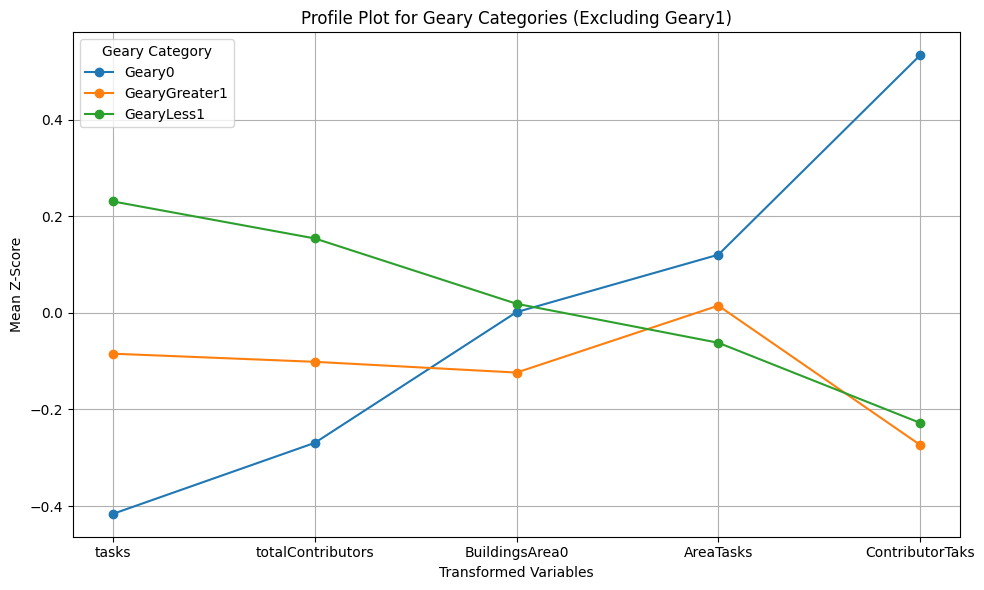

In [ ]:
data = geary

# Correct the column names based on the actual file
columns_to_transform = ['tasks', 'ContributorTaks', 'AreaTasks', 'BuildingsArea0',"totalContributors"]

# Standardization (Z-transformation)
scaler = StandardScaler()
data_z_transformed = data.copy()
data_z_transformed[columns_to_transform] = scaler.fit_transform(data[columns_to_transform])

# Filter to exclude the 'Geary1' category
filtered_data = data_z_transformed[data_z_transformed['GearyCategory'] != 'Geary1']

# Group by 'Geary' category and calculate the mean of the transformed variables
group_means = filtered_data.groupby('GearyCategory')[columns_to_transform].mean()

# Define the new order of the variables
new_order = ['tasks', "totalContributors", 'BuildingsArea0', 'AreaTasks', 'ContributorTaks']

# Create the profile plot
plt.figure(figsize=(10, 6))
for category in group_means.index:
    plt.plot(new_order, group_means.loc[category][new_order], marker='o', label=category)

plt.title('Profile Plot for Geary Categories (Excluding Geary1)')
plt.xlabel('Transformed Variables')
plt.ylabel('Mean Z-Score')
plt.legend(title='Geary Category')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Correct the column names based on the actual file
columns_to_transform = ['tasks', 'ContributorTaks', 'AreaTasks', 'BuildingsArea0',"totalContributors"]

# Standardization (Z-transformation)
scaler = StandardScaler()
data_z_transformed = data.copy()
data_z_transformed[columns_to_transform] = scaler.fit_transform(data[columns_to_transform])

# Filter to exclude the 'Geary1' category
filtered_data = data_z_transformed[data_z_transformed['GearyCategory'] != 'Geary1']

# Group by 'GearyCategory' and calculate the mean of the transformed variables
group_means = filtered_data.groupby('GearyCategory')[columns_to_transform].mean()

# Define the new order of the variables
new_order = ['tasks', "totalContributors", 'BuildingsArea0', 'AreaTasks', 'ContributorTaks']

# Reorder the columns in the table
pivot_table = group_means[new_order].reset_index()

# Display the table
pivot_table

,GearyCategory,tasks,totalContributors,BuildingsArea0,AreaTasks,ContributorTaks
0,Geary0,-0.416124,-0.269100,0.001724,0.120570,0.533722
1,GearyGreater1,-0.084473,-0.101305,-0.123564,0.015079,-0.273393
2,GearyLess1,0.230836,0.154263,0.018919,-0.061859,-0.227749


In [ ]:
# Describe Geary`s C
geary[['Geary']].describe()

,Geary
count,2972.000000
mean,0.761963
std,0.245164
min,0.000000
25%,0.608108
50%,0.768833
75%,0.908011
max,2.500000


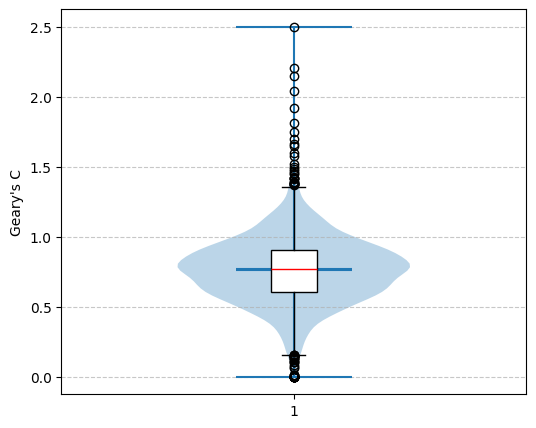

In [ ]:
# Create figure
plt.figure(figsize=(6, 5))

# Violin plot
plt.violinplot(geary[~geary['Geary'].isnull()]['Geary'], showmeans=True, showmedians=True, showextrema=True)

# Overlaid boxplot
plt.boxplot(geary[~geary['Geary'].isnull()]['Geary'], vert=True, widths=0.1, patch_artist=True,
            boxprops=dict(facecolor="white", color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            medianprops=dict(color="red"))

# Titles and labels
#plt.title('Violin plot + Boxplot of the Geary variable')
plt.ylabel('Geary\'s C')

# Grid configuration: only horizontal lines
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

plt.show()